# Projekce souřadnic pracovišť klinického hodnocení pro mapování pomocí PROC GPROJECT

## Shrnutí

Tým klinických operací potřebuje vykreslit geografické rozmístění vícepracovištní studie fáze III na plochou mapu. Tento notebook generuje syntetické souřadnice zeměpisné délky a šířky pro pracoviště studie soustředěná kolem pěti regionálních center v USA a poté pomocí **PROC GPROJECT** převádí sférické souřadnice na kartézské hodnoty X/Y třemi projekčními metodami (Albersovo stejnoplochné zobrazení, Lambertovo konformní zobrazení s vlastními standardními rovnoběžkami a oříznutím na region a gnomonické zobrazení se středem na kontinentálních USA), a znázorňuje tak, jak volba projekce a oříznutí ovlivňují mapu pracovišť.

## Zdroje dat

| Dataset | Řádky | Klíčové proměnné | Popis |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 center x 12 pracovišť) | `site_id` (ID, $8), `region` ($20), `x` (zeměpisná délka, stupně, kladná na východ), `y` (zeměpisná šířka, stupně), `enroll` (počet zapsaných pacientů), `segment` (id segmentu mapy) | Syntetická umístění pracovišť klinického hodnocení fáze III rozptýlená kolem pěti regionálních center v USA (Západ, Středozápad, Severovýchod, Jih, Jihovýchod) pomocí odchylky `rand('normal')` a počtu zapsaných `rand('poisson')` |

# Projekce souřadnic pracovišť klinického hodnocení pomocí PROC GPROJECT

Když zadavatel provádí geograficky rozptýlenou studii fáze III, skupina klinických operací často potřebuje jedinou mapu zobrazující všechna zkoušející pracoviště, velikostně nebo barevně odlišená podle náboru. Umístění pracovišť přicházejí jako **dvojice zeměpisné délky a šířky**, ale plochá mapa potřebuje **rovinné souřadnice X/Y**. `PROC GPROJECT` provádí tento převod ze sférických na kartézské souřadnice a aplikuje kartografickou projekci, aby byly vzdálenosti a plochy vykresleny smysluplně.

V tomto notebooku:

1. Vygenerujeme syntetické souřadnice pracovišť soustředěné kolem pěti regionálních center v USA.
2. Aplikujeme výchozí **Albersovo stejnoplochné** zobrazení.
3. Aplikujeme **Lambertovo konformní** zobrazení s vlastními standardními rovnoběžkami a oříznutím na souvislé USA.
4. Aplikujeme **gnomonické** zobrazení se středem v zeměpisném středu země, přičemž pomocí `ASIS` zachováme původní souřadnice.

Vše je soběstačné: žádné externí soubory, žádná síť.

## Krok 1 — Generování syntetických souřadnic pracovišť

Generátor náhodných čísel osadíme pomocí `call streaminit` pro reprodukovatelnost a poté rozmístíme 12 pracovišť kolem každého z pěti regionálních center. Zeměpisná délka je uložena kladná na východ ve stupních (záporná pro západní polokouli) a zeměpisná šířka ve stupních. Každý řádek nese také počet zapsaných pacientů a proměnnou `segment` (GPROJECT zachovává přes projekci i sloupce, které nejsou souřadnicemi).

In [1]:
data trial_sites;
    CALL streaminit(20260531);
    DÉLKA site_id $8 region $20;
    /* Pět regionálních center v USA: zeměpisná délka (východ+), šířka */
    POLE clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    POLE clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    OPAKUJ hub = 1 TO 5;
        /* Přímý přiřazovací řetězec IF/ELSE místo _temporary_ pole s
           diakritikou - vyhýbá se známé chybě zkracování hodnot u
           _temporary_ polí s neASCII řetězci. */
        KDYŽ hub = 1 PAK region = 'Západ';
        JINAK KDYŽ hub = 2 PAK region = 'Středozápad';
        JINAK KDYŽ hub = 3 PAK region = 'Severovýchod';
        JINAK KDYŽ hub = 4 PAK region = 'Jih';
        JINAK region = 'Jihovýchod';
        OPAKUJ s = 1 TO 12;
            site_id = cats('S', ZAPSAT(hub, z1.), ZAPSAT(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* zeměpisná délka, stupně */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* zeměpisná šířka, stupně */
            enroll  = round(rand('poisson', 60));           /* počet zapsaných pacientů */
            segment = 1;
            VÝSTUP;
        KONEC;
    KONEC;
    ODSTRANIT hub s;
    ŠTÍTEK site_id='ID pracoviště'
          region='Region'
          x='Souřadnice X'
          y='Souřadnice Y'
          enroll='Počet zapsaných'
          segment='Segment mapy';
SPUSTIT;

PROCEDURA TISK data=trial_sites(obs=10) ŠTÍTEK;
    NÁZEV 'Ukázka syntetických pracovišť klinického hodnocení (neprojektované zem. délka/šířka)';
SPUSTIT;

                  Ukázka syntetických pracovišť klinického hodnocení (neprojektované zem. délka/šířka)                  

  Obs    ID pracoviště  Region     Souřadnice X   Souřadnice Y    Počet zapsaných  Segment mapy
    1  S101             Západ   -121.6437232216  37.7677668495                 65             1
    2  S102             Západ   -120.7384024716  37.5083287903                 61             1
    3  S103             Západ   -121.5133780284  37.8633933883                 72             1
    4  S104             Západ   -121.2086817368  38.7723343392                 68             1
    5  S105             Západ   -121.0499572297   37.175813806                 54             1
    6  S106             Západ   -124.0531899967   35.778231667                 72             1
    7  S107             Západ   -120.9370181032  39.0576714397                 64             1
    8  S108             Západ   -126.8495029747  36.6474680375                 55             1
    9  S109   


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Krok 2 — Výchozí Albersovo stejnoplochné zobrazení

**Albersovo** stejnoplochné kuželové zobrazení je výchozí volbou v GPROJECT a rozumnou volbou pro mapu v měřítku celé země, kde záleží na zachování *relativní plochy* (např. při porovnávání velikosti spádových oblastí regionů).

Protože naše souřadnice jsou uloženy ve **stupních** s **kladnou zeměpisnou délkou na východ**, uvádíme volby `DEGREE` a `EASTLONG`. Příkaz `ID` určuje proměnnou, která jednoznačně identifikuje každou jednotku; projektované rovinné souřadnice se zapíší zpět do `x` a `y` v datasetu `OUT=`.

In [2]:
PROCEDURA GPROJECT data=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
SPUSTIT;

PROCEDURA TISK data=sites_albers(obs=10) ŠTÍTEK;
    NÁZEV 'Pracoviště po Albersově stejnoplochém zobrazení (rovinné X/Y)';
SPUSTIT;

                  Ukázka syntetických pracovišť klinického hodnocení (neprojektované zem. délka/šířka)                  

                             Pracoviště po Albersově stejnoplochém zobrazení (rovinné X/Y)                              

  Obs  site_id  region              x             y  enroll  segment
    1  S101     Západ    -0.346124731  0.0516986079      65        1
    2  S102     Západ   -0.3353644139  0.0440400181      61        1
    3  S103     Západ   -0.3439609675  0.0528501365      72        1
    4  S104     Západ   -0.3357513354   0.067213083      68        1
    5  S105     Západ   -0.3410170723  0.0394882801      54        1
    6  S106     Západ   -0.3879364507  0.0273340733      72        1
    7  S107     Západ   -0.3309127579  0.0711146305      64        1
    8  S108     Západ   -0.4204191205  0.0538118922      55        1
    9  S109     Západ    -0.373326801  0.0480459173      56        1
   10  S110     Západ   -0.3625020177  0.0410031251      57       


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Krok 3 — Lambertovo konformní zobrazení s vlastními rovnoběžkami a oříznutím

**Lambertovo konformní** kuželové zobrazení zachovává *tvar a místní úhly*, což je výhodné, pokud se mapa používá pro navigaci nebo pro překrytí směrových prvků. Pro souvislé USA jsou obvyklé standardní rovnoběžky kolem 33 st. s. š. a 45 st. s. š., proto je explicitně nastavíme pomocí `PARALLEL1=` a `PARALLEL2=`.

Mapu také omezíme na okno souvislých USA pomocí ořezových voleb `LATMIN=`, `LATMAX=`, `LONGMIN=` a `LONGMAX=`. Jakákoli pracoviště mimo tento box zeměpisné šířky a délky se před projekcí vyřadí, takže počet výstupních pozorování může být nižší než počet vstupních.

In [3]:
PROCEDURA GPROJECT data=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
SPUSTIT;

PROCEDURA TISK data=sites_lambert(obs=10) ŠTÍTEK;
    NÁZEV 'Pracoviště po Lambertově konformním zobrazení (oříznuto na souvislé USA)';
SPUSTIT;

                             Pracoviště po Albersově stejnoplochém zobrazení (rovinné X/Y)                              

                        Pracoviště po Lambertově konformním zobrazení (oříznuto na souvislé USA)                        

  Obs  site_id  region              x             y  enroll  segment
    1  S101     Západ   -0.3473024124  0.0279382533      65        1
    2  S102     Západ   -0.3365626234  0.0201991247      61        1
    3  S103     Západ   -0.3451238364  0.0290365995      72        1
    4  S104     Západ   -0.3367881094  0.0430616123      68        1
    5  S105     Západ   -0.3422656751  0.0158037156      54        1
    6  S106     Západ   -0.3894389642  0.0046370991      72        1
    7  S107     Západ   -0.3319086764  0.0468276119      64        1
    8  S109     Západ   -0.3746144745  0.0248234546      56        1
    9  S110     Západ   -0.3638098935  0.0176740311      57        1
   10  S111     Západ   -0.3789327542  0.0295539096      49       


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Krok 4 — Gnomonické zobrazení se středem v zemi, se zachováním původních souřadnic

**Gnomonické** azimutální zobrazení vykresluje každou hlavní kružnici jako přímku, což se hodí, když potřebujete uvažovat o nejkratší cestě mezi pracovišti (například při plánování trasy monitorovací návštěvy pracovišť). Zkreslení roste se vzdáleností od pólu projekce, proto pól umístíme do zeměpisného středu kontinentálních USA pomocí `POLELAT=39` a `POLELONG=-98`.

Volba `ASIS` říká GPROJECT, aby zachoval původní neprojektované souřadnice vedle projektovaných hodnot, takže výstupní dataset nese jak rovinné `X`/`Y`, tak zdrojové `LONG`/`LAT` — hodí se pro zpětné spojení metrik náboru s kterýmkoli souřadnicovým prostorem.

Příkaz `PARMENTRY` je ukázán jako alternativní způsob, jak zadat projekční parametry formou přepisů klíč=hodnota.

In [4]:
PROCEDURA GPROJECT data=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
SPUSTIT;

PROCEDURA TISK data=sites_gnomon(obs=10) ŠTÍTEK;
    NÁZEV 'Pracoviště po gnomonickém zobrazení (ASIS zachovává původní LONG/LAT)';
SPUSTIT;

                        Pracoviště po Lambertově konformním zobrazení (oříznuto na souvislé USA)                        

                         Pracoviště po gnomonickém zobrazení (ASIS zachovává původní LONG/LAT)                          

  Obs  site_id  region              x              y  enroll  segment             LONG            LAT
    1  S101     Západ   -0.3343477981   0.0213614461      65        1  -121.6437232216  37.7677668495
    2  S102     Západ   -0.3221611694   0.0134152735      61        1  -120.7384024716  37.5083287903
    3  S103     Západ   -0.3319480803   0.0225717184      72        1  -121.5133780284  37.8633933883
    4  S104     Západ   -0.3230855797   0.0375741352      68        1  -121.2086817368  38.7723343392
    5  S105     Západ   -0.3283677206   0.0086308769      54        1  -121.0499572297   37.175813806
    6  S106     Západ   -0.3813558012  -0.0046248781      72        1  -124.0531899967   35.778231667
    7  S107     Západ   -0.3177843326    0


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Krok 5 — Vykreslení projektované mapy pracovišť

Smyslem celé projekce je nakreslit mapu. Dataset `OUT=` z Albersovy projekce přivedeme přímo do **PROC SGPLOT**, kde vykreslíme rovinné `X`/`Y` a obarvíme každý bod podle `region`. Protože projekce zachovala relativní geografii, pět shluků center skončí v očekávaných rozích grafu — Západ vlevo, Severovýchod vpravo nahoře, Jih a Jihovýchod dole — což klinickým operacím poskytuje plošně věrné rozmístění popsané ve shrnutí.

                         Pracoviště po gnomonickém zobrazení (ASIS zachovává původní LONG/LAT)                          




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


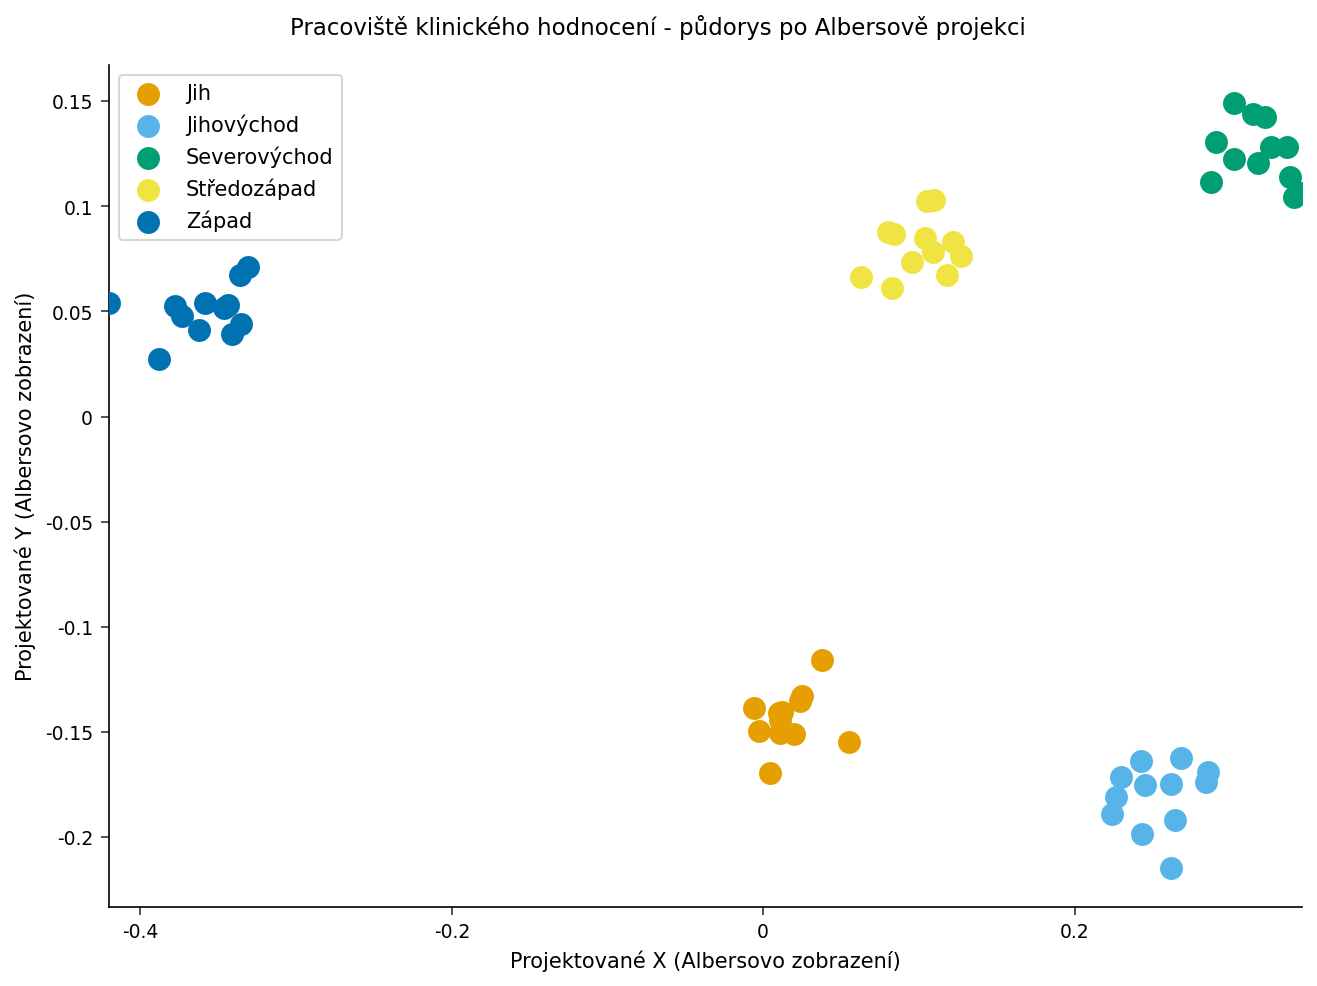

In [5]:
PROCEDURA SGPLOT data=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS ŠTÍTEK='Projektované X (Albersovo zobrazení)';
    YAXIS ŠTÍTEK='Projektované Y (Albersovo zobrazení)';
    NÁZEV 'Pracoviště klinického hodnocení - půdorys po Albersově projekci';
SPUSTIT;

## Interpretace výsledků

- **Albersovo zobrazení (krok 2)** převedlo všech 60 pracovišť na rovinné souřadnice při zachování relativní plochy — shluky Západ, Středozápad, Severovýchod, Jih a Jihovýchod si zachovávají poměrné prostorové rozmístění, což je správný základ pro plošně věrnou teplotní mapu náboru.
- **Lambertovo zobrazení s oříznutím (krok 3)** zachovalo místní tvar a aplikací okna `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX` vyřadilo syntetická pracoviště, která se rozptýlila mimo souvislé USA — počet zde klesl z 60 na 58, takže dvě souřadnice mimo mřížku, které by jinak mapu natáhly, byly před projekcí odstraněny.
- **Gnomonické zobrazení s `ASIS` (krok 4)** vycentrovalo projekci na vnitrozemí země a díky `ASIS` vytvořilo dataset, který nese jak projektované `X`/`Y`, tak původní `LONG`/`LAT`. Hlavní kružnice se zobrazují jako přímky, takže přímé vzdálenosti na této mapě aproximují skutečné nejkratší cesty mezi pracovišti.
- **Vykreslené rozmístění (krok 5)** potvrzuje, že projekce fungovala: vykreslení Albersových `X`/`Y` podle regionu umístí pět shluků center do očekávaných rohů roviny — plošně věrnou mapu pracovišť slíbenou ve shrnutí.

**Ponaučení pro klinické operace:** projekce není jen kosmetická záležitost. Zvolte **Albersovo zobrazení** pro plošně věrnou hustotu náboru, **Lambertovo zobrazení** pro tvarově věrné překryvy s regionálním oříznutím a **gnomonické zobrazení**, pokud analýzu řídí vzdálenost cesty mezi pracovišti. Jak ukazuje krok 5, projektovaný dataset `OUT=` se přímo vloží do PROC SGPLOT (nebo PROC GMAP) pro vykreslení finální mapy pracovišť.